## Thesis plots

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from sklearn.metrics import root_mean_squared_error


base_dir = os.path.dirname(os.path.abspath(""))
thesis_fig_folder = os.path.join(base_dir, 'Thesis report', 'figures_thesis')

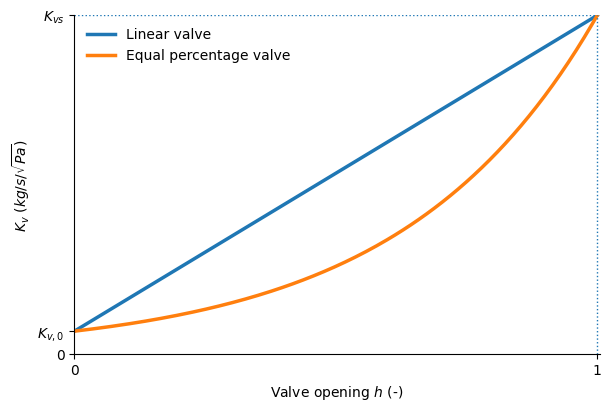

In [2]:
# -----------------------
# Ideal valve functions
# -----------------------

def linear_valve_func(h, Kvs, Kv0):
    return Kv0 + h * (Kvs - Kv0)


def equal_percentage_ideal(h, Kvs, Kv0):
    return (Kvs / Kv0) ** (h - 1) * Kvs


# -----------------------
# Parameters
# -----------------------

h_array = np.linspace(0, 1, 200)

Kvs = 0.003
Kv0 = Kvs / 15   # or Kvs/25 depending on your definition

Kv_linear = linear_valve_func(h_array, Kvs, Kv0)
Kv_equal = equal_percentage_ideal(h_array, Kvs, Kv0)

# -----------------------
# Plot
# -----------------------

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

ax.plot(h_array, Kv_linear, lw=2.5, label='Linear valve')
ax.plot(h_array, Kv_equal, lw=2.5, label='Equal percentage valve')

ax.plot([0,1], [Kvs, Kvs], color='C0',ls = ':', lw=1)
ax.plot([1,1], [0, Kvs], color='C0', ls = ':', lw=1)

# Limits
ax.set_xlim(0, 1.005)
ax.set_ylim(0, Kvs)

# Labels
ax.set_xlabel(r'Valve opening $h$ (-)')
ax.set_ylabel(r'$K_v$ $(kg/s/\sqrt{Pa}$)')

# Clean ticks
ax.set_xticks([0, 1])
ax.set_xticklabels(['0', '1'])

ax.set_yticks([0, Kv0, Kvs])
ax.set_yticklabels(['0', r'$K_{v,0}$', r'$K_{vs}$'])

# Style
# ax.grid(alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False)

plt.savefig(os.path.join(thesis_fig_folder, 'Kvplots_ideal.png'), dpi=150, bbox_inches='tight')
plt.show()

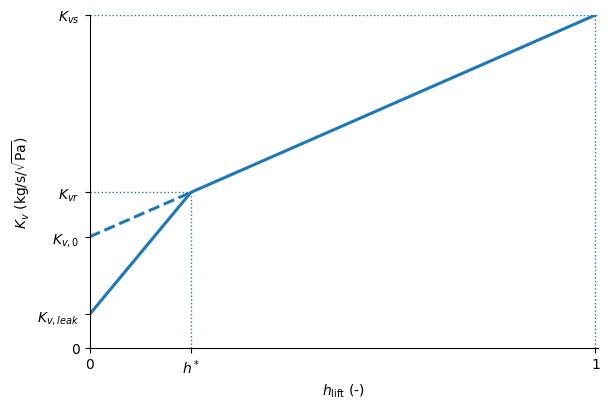

In [3]:
# -----------------------
# Parameters
# -----------------------
Kvs = 1
Kv0 = Kvs / 3
Kv_leak = Kvs / 10
h_star = 0.2

# -----------------------
# Ideal characteristics
# -----------------------
def linear_valve_func(h, Kvs, Kv0, Kvleak, h_star):
    def linear_ideal_func(h):
        return h * (Kvs - Kv0) + Kv0

    if h < h_star:
        Kv = Kvleak + h*(linear_ideal_func(h_star) - Kvleak)/h_star
    else:
        Kv = linear_ideal_func(h)
    return Kv

# -----------------------
# Data
# -----------------------
h_array = np.linspace(0, 1, 500)
Kv_lin_array = np.zeros(len(h_array))
Kv_ideal_lin_array = np.zeros(len(h_array))
for i,h in enumerate(h_array):
    Kv_lin_array[i] = linear_valve_func(h, Kvs, Kv0, Kv_leak, h_star)
    Kv_ideal_lin_array[i] = linear_valve_func(h, Kvs, Kv0, Kv_leak, 0)

# key point at h*
Kvr = linear_valve_func(h_star, Kvs, Kv0, Kv_leak, h_star)

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(6.2, 4.2))

# Curves
ax.plot(h_array, Kv_lin_array, color='C0', lw=2.2, label='Linear')
ax.plot(h_array[h_array < h_star], Kv_ideal_lin_array[h_array < h_star], color='C0', ls = '--', lw=2.2)

# # Leakage / low-opening approximation (piecewise hint line)
# ax.plot([0, h_star], [Kv_leak,], color='C0', lw=1.2)

# Construction lines at h*
ax.plot([h_star, h_star], [0, Kvr], color='C0', ls=':', lw=1)
ax.plot([0, h_star], [Kvr, Kvr], color='C0', ls=':', lw=1)

ax.plot([0,1], [Kvs, Kvs], color='C0', ls = ':', lw=1)
ax.plot([1,1], [0, Kvs], color='C0', ls = ':', lw=1)

# -----------------------
# Text annotations
# -----------------------
# Clean ticks
ax.set_xticks([0,h_star, 1])
ax.set_xticklabels(['0', r'$h^*$', '1'])

ax.set_yticks([0, Kv_leak, Kv0, Kvr, Kvs])
ax.set_yticklabels(['0', r'$K_{v,leak}$', r'$K_{v,0}$', r'$K_{vr}$', r'$K_{vs}$'])

# -----------------------
# Axes styling
# -----------------------
ax.set_xlim(0, 1.005)
ax.set_ylim(0, Kvs)

ax.set_xlabel(r'$h_{\mathrm{lift}}$ (-)')
ax.set_ylabel(r'$K_v$ (kg/s/$\sqrt{\mathrm{Pa}}$)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(os.path.join(thesis_fig_folder, 'Kvplots_linear_real.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Actuator control

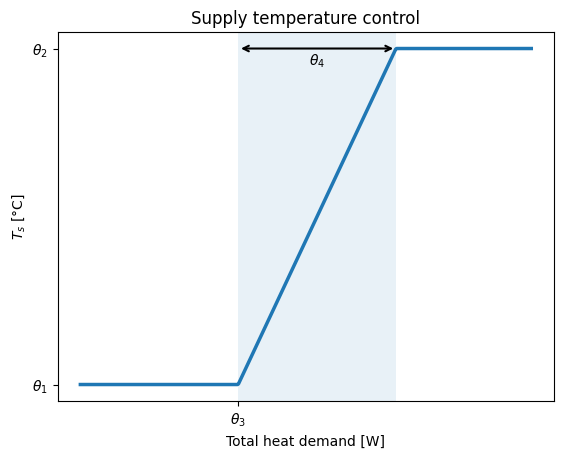

In [5]:
# X-axis
x = np.linspace(0, 200, 500)  # total heat demand [W]

# Supply temperature profile (decreasing)
T_sup = np.zeros_like(x)

T_sup_min = 60 # theta1
T_sup_max = 65 # theta2
P_band = 70 # theta3
P_band_end = 140 # theta4

for i, xi in enumerate(x):
    if xi < P_band_end - P_band:
        T_sup[i] = T_sup_min          # constant region
    elif xi <= P_band_end:
        T_sup[i] = T_sup_min + (xi - P_band_end + P_band) * (T_sup_max - T_sup_min) / (P_band)  # linear P-band
    else:
        T_sup[i] = T_sup_max          # saturated region

# Plot
plt.figure()
plt.plot(x, T_sup, lw = 2.5, color = 'C0')

plt.xlabel("Total heat demand [W]")
plt.ylabel(r"$T_s$ [°C]")
plt.title("Supply temperature control")
# Draw double arrow for P-band
plt.annotate(
    '', 
    xy=(P_band_end, T_sup_max),      # right end of P-band
    xytext=(P_band_end - P_band, T_sup_max),  # left end of P-band
    arrowprops=dict(arrowstyle='<->', linewidth=1.5)
)

# Label the P-band
plt.text((P_band_end - P_band + P_band_end) / 2, T_sup_max - 0.25, r'$\theta_4$', ha='center')

ax = plt.gca()
# ax.axhline(55, linestyle='--', linewidth=1.5)
# ax.text(
#     ax.get_xlim()[0], 55,
#     r' $T_{set}$',
#     va='center',
#     ha='left'
# )
# Y-axis thetas
plt.yticks([T_sup_min, T_sup_max], [r"$\theta_1$", r"$\theta_2$"])
# X-axis thetas
plt.xticks([P_band_end - P_band], [r"$\theta_3$"])
plt.axvspan(P_band_end - P_band, P_band_end, alpha=0.1)

plt.savefig(os.path.join(thesis_fig_folder, 'supply_control.png'), dpi=150, bbox_inches='tight')

plt.show()


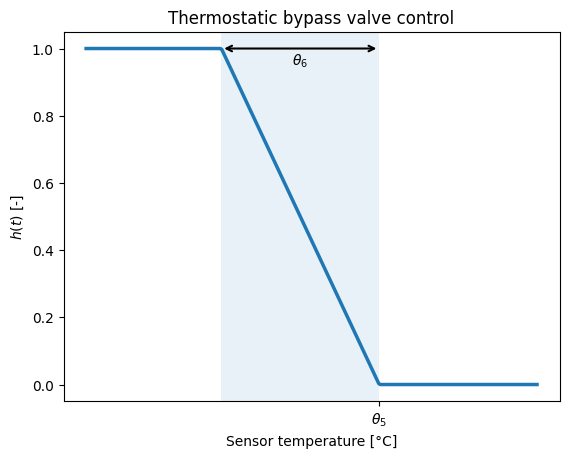

In [ ]:
# X-axis
x = np.linspace(50, 60, 300)

# Supply temperature profile (decreasing)
h_valve = np.zeros_like(x)

P_band_start = 53
P_band_end = 56.5

for i, xi in enumerate(x):
    if xi < P_band_start:
        h_valve[i] = 1   # high constant region (θ2)
    elif xi <= P_band_end:
        h_valve[i] = 1 - (xi - P_band_start) / (P_band_end - P_band_start)  # linear decrease
    else:
        h_valve[i] = 0   # low constant region (θ1)

# Plot
plt.figure()
plt.plot(x, h_valve, lw = 2.5, color = 'C0')

plt.xlabel("Sensor temperature [°C]")
plt.ylabel(r"$h(t)$ [-]")
plt.title("Thermostatic bypass valve control")

# Draw double arrow for P-band
plt.annotate(
    '', 
    xy=(P_band_end, 1.0),      # right end of P-band
    xytext=(P_band_start, 1.0),  # left end of P-band
    arrowprops=dict(arrowstyle='<->', linewidth=1.5)
)

# Label the P-band
plt.text((P_band_start + P_band_end) / 2, 0.95, r'$\theta_6$', ha='center')

# X-axis thetas
plt.xticks([P_band_end], [r"$\theta_5$"])
plt.axvspan(P_band_start, P_band_end, alpha=0.1)

plt.savefig(os.path.join(thesis_fig_folder, 'bypass_valve_control.png'), dpi=300, bbox_inches='tight')
plt.show()



# Pipeline verification

RMSE Modelica: 5.66
RMSE Node Method: 2.84


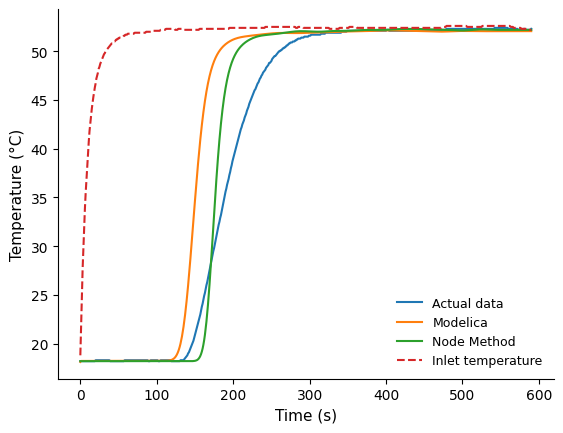

RMSE Modelica: 2.28
RMSE Node Method: 1.28


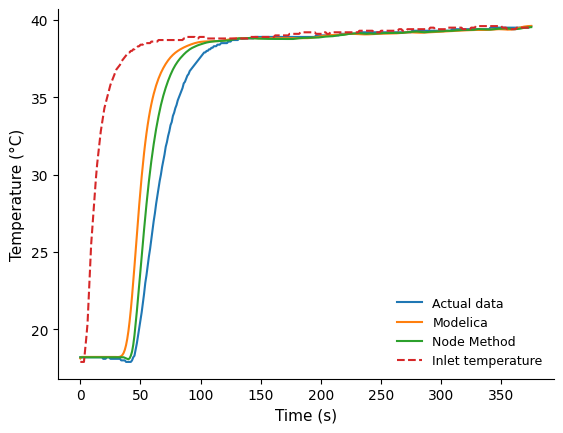

RMSE Modelica: 3.55
RMSE Node Method: 1.68


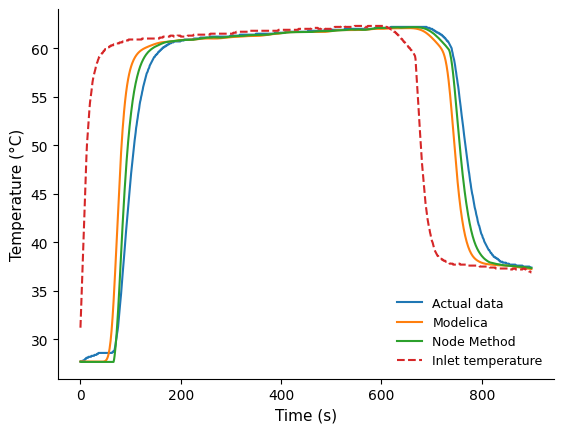

RMSE Modelica: 0.38
RMSE Node Method: 0.3


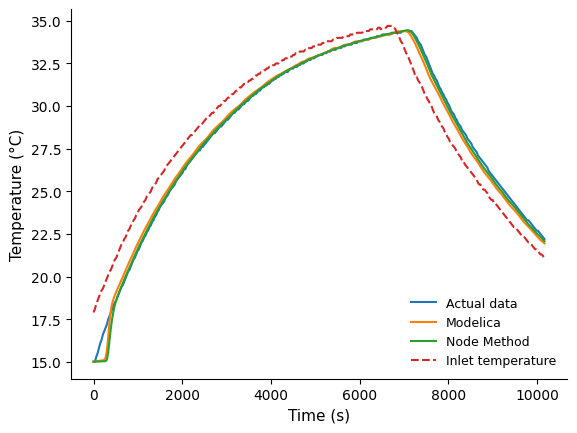

In [ ]:
## Obtain saved data 

folder = os.path.join(base_dir, "figures", "pipe_validation", "exp_simulation_modelica")

experiments = ['A', 'B', 'C', "D"]

for file in experiments:

    if file != 'D':
        dt = '1' 
    else: 
        dt = '30'
    folder_experiment = os.path.join(folder, f'Experiment{file}_dt={dt}_Tambt=18')

    data = pd.read_csv(os.path.join(folder_experiment,'comparison_data.csv'))

    mo_temp = data['Modelica temp']
    real_temp = data['Exp temp']
    nm_temp = data['Simulation temp']

    time = data['Time']
    Tin = data['Input temp simulation']

    plt.figure()

    plt.plot(time,real_temp, label = "Actual data")
    plt.plot(time,mo_temp, label = f'Modelica')
    plt.plot(time,nm_temp, label = f'Node Method')
    plt.plot(time,Tin, label = 'Inlet temperature',linestyle = '--')
    print(f"RMSE Modelica: {round(root_mean_squared_error(real_temp,mo_temp),2)}")
    print(f"RMSE Node Method: {round(root_mean_squared_error(real_temp, nm_temp),2)}")

    # plt.title(f"Temperature comparison: Experiment {file} ")
    plt.xlabel('Time (s)')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    # plt.grid(True)
    plt.savefig(os.path.join(thesis_fig_folder, f'experiment{file}.png'))
    plt.savefig(os.path.join(thesis_fig_folder, f'experiment{file}.pdf'))

    plt.show()




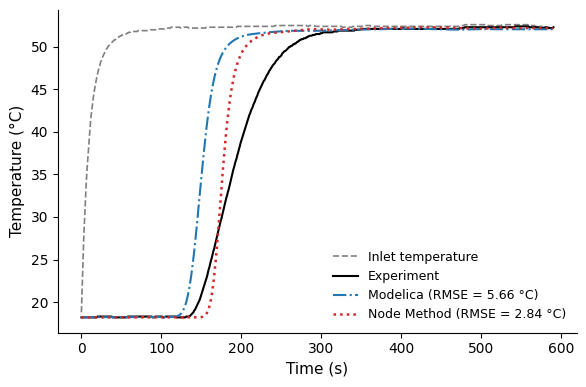

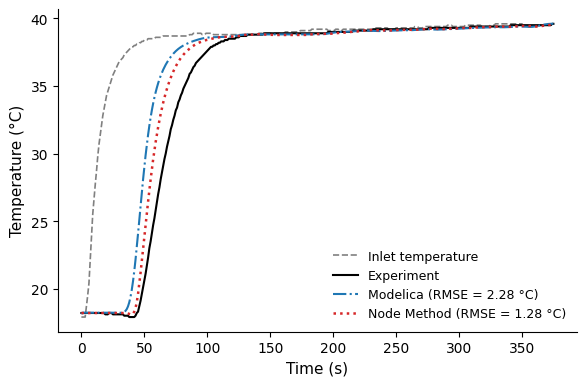

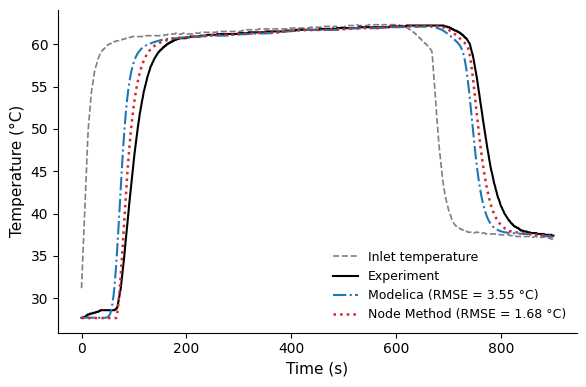

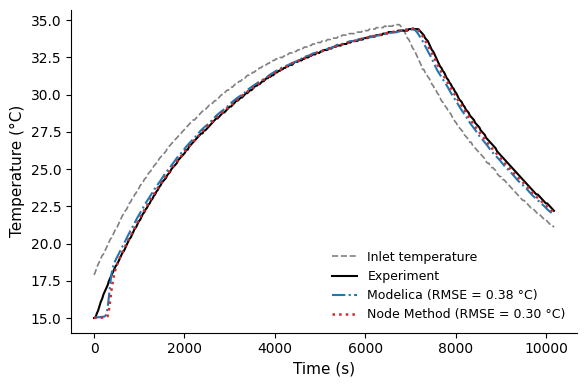

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error

# ---------------------------------------------------------------------------
# Thesis plot style (set once)
# ---------------------------------------------------------------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
})

# ---------------------------------------------------------------------------
# Obtain saved data
# ---------------------------------------------------------------------------
folder = os.path.join(base_dir, "figures", "pipe_validation", "exp_simulation_modelica")
experiments = ['A', 'B', 'C', 'D']

for exp in experiments:
    dt = '30' if exp == 'D' else '1'
    folder_experiment = os.path.join(folder, f'Experiment{exp}_dt={dt}_Tambt=18')
    data = pd.read_csv(os.path.join(folder_experiment, 'comparison_data.csv'))

    time      = data['Time']
    real_temp = data['Exp temp']
    mo_temp   = data['Modelica temp']
    nm_temp   = data['Simulation temp']
    Tin       = data['Input temp simulation']

    rmse_mo = root_mean_squared_error(real_temp, mo_temp)
    rmse_nm = root_mean_squared_error(real_temp, nm_temp)

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(time, Tin,       color='grey',    linestyle='--', linewidth=1.2,
            label='Inlet temperature')
    ax.plot(time, real_temp, color='black',   linestyle='-',  linewidth=1.5,
            label='Experiment')
    ax.plot(time, mo_temp,   color='tab:blue', linestyle='-.', linewidth=1.5,
            label=f'Modelica (RMSE = {rmse_mo:.2f} °C)')
    ax.plot(time, nm_temp,   color='tab:red',  linestyle=':',  linewidth=1.8,
            label=f'Node Method (RMSE = {rmse_nm:.2f} °C)')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Temperature (°C)')
    ax.legend(loc='best')

    fig.tight_layout()
    fig.savefig(os.path.join(thesis_fig_folder, f'experiment{exp}.pdf'),
                dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(thesis_fig_folder, f'experiment{exp}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)